In [ ]:
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import os
import copy
import sys 
sys.path.append("..")
import scipy

In [ ]:
import src.model_systems as model_systems
import src.helpers as helpers
import src.potentials as potentials
import src.diffusion_map as diffusion_map

# Butane

In [ ]:
fname = "butane_metad_aligned.npz" #butane_metad.npz DNMTBut.npz butane_hightemp.npz
inData = np.load(fname)
print("Keys in data:")
print(list(inData.keys()))

data_meta = inData["data_all_atom"]
dataMetaD = data_meta
print("Data shape from trajectory:")
print(dataMetaD.shape)
dihedralsMetaD = inData["dihedrals"] # the one dim dihedral angles
potentialMetaD = inData["potential"] # potential related to the particular data point
print(potentialMetaD.shape)
print(dihedralsMetaD.shape)
kbT_roomtemp = inData["kbT_roomtemp"]
dataMetaD = dataMetaD[::20,:]
dihedralsMetaD = dihedralsMetaD[::20]
potentialMetaD = potentialMetaD[::20]

Keys in data:
['data', 'data_all_atom', 'dihedrals', 'potential', 'kbT', 'kbT_roomtemp', 'free_energy', 'biasFactor', 'biasWidth', 'height', 'frequency']
Data shape from trajectory:
(200000, 42)
(200000,)
(200000,)


In [ ]:
def epsilon_net(data, ϵ):

    #initialize the net

    dense = True # parameter that checks whether the net is still dense
    # ϵ = 0.005
    iter = 0 
    ϵ_net = np.array(range(data.shape[1]))
    current_point_index = ϵ_net[0]

    #fill the net

    while dense:
        current_point = data[:,current_point_index] # set current point
        ϵ_ball = np.where(np.linalg.norm(data - np.tile(current_point.reshape(current_point.shape[0],1), 
                                                        (1,data.shape[1])), axis=0) <= ϵ)[0] # get indices for ϵ-ball
        ϵ_net = np.delete(ϵ_net, np.where(np.isin(ϵ_net, ϵ_ball))) # kill elements from the ϵ-ball from the net
        ϵ_net = np.append(ϵ_net, current_point_index) # add the current point at the BACK OF THE QUEUE. THIS IS KEY
        current_point_index = ϵ_net[0] # set current point for killing an epsilon ball in the next iteration
        if current_point_index == 0: # if the current point is the initial one, we are done! 
            dense = False
    return ϵ_net, data[:,ϵ_net]

In [ ]:
# Create a boolean vector with all False values

subsampling_scheme = "Time-uniform"
if subsampling_scheme == "Time-uniform":
    subsamples = np.zeros(dataMetaD.shape[0], dtype=bool)
    subsamples[9::10] = True
elif subsampling_scheme == "Metastable": 
    subsamples = np.logical_or(np.abs(dihedralsMetaD-np.pi) < 0.2, np.abs(dihedralsMetaD-np.pi/3) < 0.1, np.abs(dihedralsMetaD-5*np.pi/3) < 0.1)
    subsamples = ~subsamples
elif subsampling_scheme == "deltanet":
    delta_net, _ = epsilon_net(dataMetaD.T, 1.0)
    subsamples = np.ones(dataMetaD.shape[0], dtype=bool)    
    subsamples[delta_net] = False
else:
    raise ValueError("Unknown subsampling scheme")

# Dmap

In [ ]:
data = dataMetaD[subsamples, :]
dihedrals = dihedralsMetaD[subsamples]
potentials = potentialMetaD[subsamples]
target_measure = np.exp(-potentials/(kbT_roomtemp))
# 1: compute dmap 
# Fiedler vector: 
dmap_obj = diffusion_map.DiffusionMap(alpha=0.5,epsilon=50.0,num_evecs=15, n_neigh=128)
dmap_obj.construct_generator(data.T)
L_dmap = dmap_obj.get_generator()
dmap, devecs3, devals3 = dmap_obj._construct_diffusion_coords(L_dmap)

# Nmap

In [ ]:
# 2: neumann eigenmap
nmap_obj = diffusion_map.NeumannMap(alpha=0.5,epsilon=50.0,num_evecs=15)

In [ ]:
nmap_obj.construct_generator(dataMetaD.T, subsamples)
L_nmap = nmap_obj.get_generator()
nmap, nevecs3, nevals3 = nmap_obj._construct_diffusion_coords(L_nmap)

computing eigvec matrix


# Fit results

In [ ]:
dihedrals_indices = np.logical_and(1.0 <= dihedrals, dihedrals <= 5.0)
fit_dihedrals = dihedrals[dihedrals_indices].reshape(-1,1)
fit_dmap = dmap[dihedrals_indices, 0].reshape(-1,1)
fit_nm = nmap[dihedrals_indices, 0].reshape(-1,1)

In [ ]:
from sklearn.linear_model import LinearRegression

def calculate_standard_error(X, y, model):
    predictions = model.predict(X)
    residuals = y - predictions
    residual_sum_of_squares = np.sum(residuals**2)
    degrees_of_freedom = X.shape[0] - X.shape[1] - 1
    residual_variance = residual_sum_of_squares / degrees_of_freedom
    X_with_intercept = np.hstack([np.ones((X.shape[0], 1)), X])
    covariance_matrix = residual_variance * np.linalg.inv(X_with_intercept.T @ X_with_intercept)
    standard_errors = np.sqrt(np.diag(covariance_matrix))
    return standard_errors

# Fit linear regression for (fit_dihedrals, fit_dmap)
reg_dmap = LinearRegression().fit(fit_dihedrals, fit_dmap)
dmap_pred = reg_dmap.predict(fit_dihedrals)
r2_dmap = reg_dmap.score(fit_dihedrals, fit_dmap)
se_dmap = calculate_standard_error(fit_dihedrals, fit_dmap, reg_dmap)

# Fit linear regression for (fit_dihedrals, fit_nm)
reg_nm = LinearRegression().fit(fit_dihedrals, fit_nm)
nm_pred = reg_nm.predict(fit_dihedrals)
r2_nm = reg_nm.score(fit_dihedrals, fit_nm)
se_nm = calculate_standard_error(fit_dihedrals, fit_nm, reg_nm)

R² value for (fit_dihedrals, fit_dmap): 5.950326523729288e-07
Standard error for (fit_dihedrals, fit_dmap): [0.05364541 0.01679051]
R² value for (fit_dihedrals, fit_nm): 0.9912658388121556
Standard error for (fit_dihedrals, fit_nm): [3.13373793e-04 9.80830321e-05]


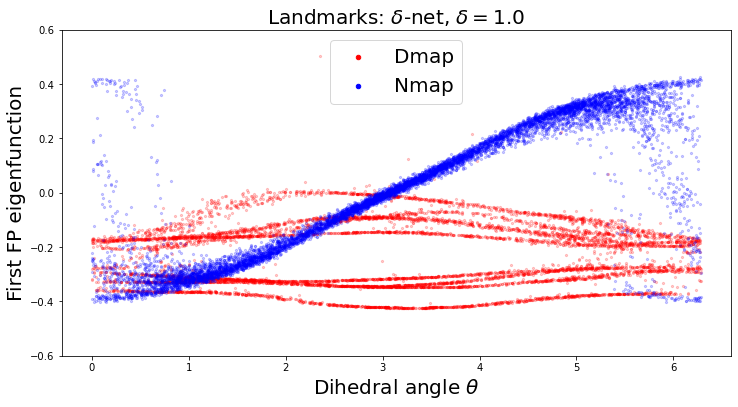

In [ ]:
# Print R² values and standard errors
print(f'R² value for (fit_dihedrals, fit_dmap): {r2_dmap}')
print(f'Standard error for (fit_dihedrals, fit_dmap): {se_dmap}')
print(f'R² value for (fit_dihedrals, fit_nm): {r2_nm}')
print(f'Standard error for (fit_dihedrals, fit_nm): {se_nm}')

# Plot the results
plt.figure(figsize=(12, 6))

# Plot for (fit_dihedrals, fit_dmap)
# plt.subplot(1, 2, 1)
plt.scatter(dihedrals, 0.5*dmap[:,0], color = 'red', alpha=0.2, s=5.0)
plt.scatter([],[], color='red', alpha=1.0, s=20.0, label="Dmap")
# plt.plot(fit_dihedrals, 0.5*dmap_pred, color='red', label=f'Dmap, SE = {se_dmap[0]:.4f}')
plt.scatter(dihedrals, 2.0*nmap[:,0], color = 'blue', alpha=0.2, s=5.0)
plt.scatter([],[], color='blue', alpha=1.0, s=20.0, label="Nmap")
# plt.plot(fit_dihedrals, 2.0*nm_pred, color='blue', label=f'Nmap, SE = {se_nm[0]:.4f}')
plt.xlabel(r'Dihedral angle $\theta$', fontsize=20)
plt.ylabel('First FP eigenfunction', fontsize=20)
plt.ylim((-0.6,0.6))
plt.title(r'Landmarks: $\delta$-net, $\delta=1.0$', fontsize=20)
plt.legend(fontsize=20)
plt.savefig('Dihedral_angle_deltanet_subsampling.png')

In [ ]:
# save
np.savez('butane_experiment_metastable_subsampling.npz', \
         note="subsample original data by 20. points for neumann embedding are further given by transition states, remove radius 0.2 around pi and 0.1 around pi/3 and 5pi/3", \
         dmap=dmap, devecs3=devecs3, devals3=devals3, nmap=nmap, nevecs3=nevecs3, nevals3=nevals3, \
        alpha=1.0, epsilon=50.0, num_evecs=15)